# Welcome to Colab!

In [1]:
import pandas as pd

df = pd.read_csv('laptop.csv')
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8.0,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8.0,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8.0,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16.0,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8.0,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [2]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(1275, 15)
['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)']
Company                0
Product                8
TypeName               8
Inches                 8
ScreenResolution       8
CPU_Company            8
CPU_Type               8
CPU_Frequency (GHz)    8
RAM (GB)               8
Memory                 8
GPU_Company            8
GPU_Type               8
OpSys                  8
Weight (kg)            8
Price (Euro)           8
dtype: int64


In [3]:
# Remove rows with missing values
df = df.dropna()

# Confirm they're gone
print(df.shape)
print(df.isnull().sum().sum())

(1267, 15)
0


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['CPU_Type_Encoded'] = le.fit_transform(df['CPU_Type'])

# Update X to include the encoded column
X = df[['RAM (GB)', 'CPU_Frequency (GHz)', 'Weight (kg)', 'Inches', 'CPU_Type_Encoded']]
y = df['Price (Euro)']

print(df[['CPU_Type', 'CPU_Type_Encoded']].drop_duplicates().head(10))

          CPU_Type  CPU_Type_Encoded
0          Core i5                37
2    Core i5 7200U                43
3          Core i7                51
5   A9-Series 9420                11
8    Core i7 8550U                67
9    Core i5 8250U                50
11   Core i3 6006U                33
16   Core i7 7500U                59
18   Core i3 7100U                35
20   Atom x5-Z8350                15


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(1013, 5)
(254, 5)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} Euros")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 314.69 Euros
R2 Score: 0.66


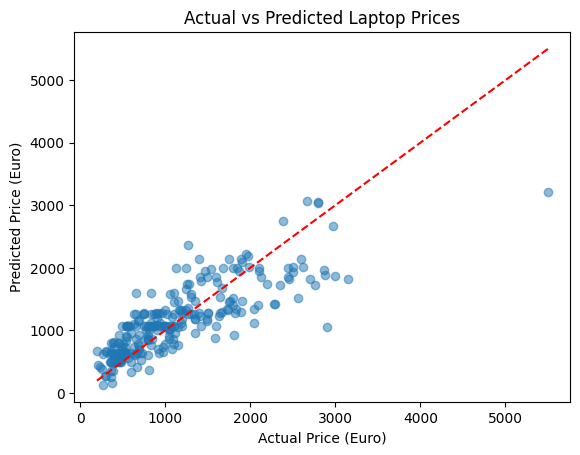

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price (Euro)")
plt.ylabel("Predicted Price (Euro)")
plt.title("Actual vs Predicted Laptop Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [9]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_mae = mean_absolute_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

print(f"KNN MAE: {knn_mae:.2f} Euros")
print(f"KNN R2 Score: {knn_r2:.2f}")

KNN MAE: 237.31 Euros
KNN R2 Score: 0.77


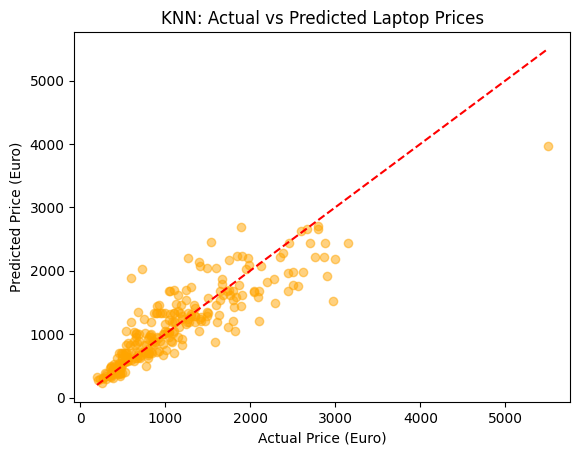

In [10]:
plt.scatter(y_test, knn_pred, alpha=0.5, color='orange')
plt.xlabel("Actual Price (Euro)")
plt.ylabel("Predicted Price (Euro)")
plt.title("KNN: Actual vs Predicted Laptop Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: {rf_mae:.2f} Euros")
print(f"Random Forest R2 Score: {rf_r2:.2f}")

Random Forest MAE: 221.97 Euros
Random Forest R2 Score: 0.80


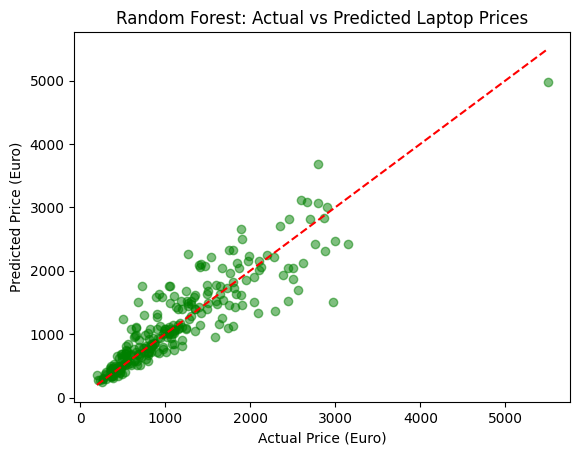

In [12]:
plt.scatter(y_test, rf_pred, alpha=0.5, color='green')
plt.xlabel("Actual Price (Euro)")
plt.ylabel("Predicted Price (Euro)")
plt.title("Random Forest: Actual vs Predicted Laptop Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

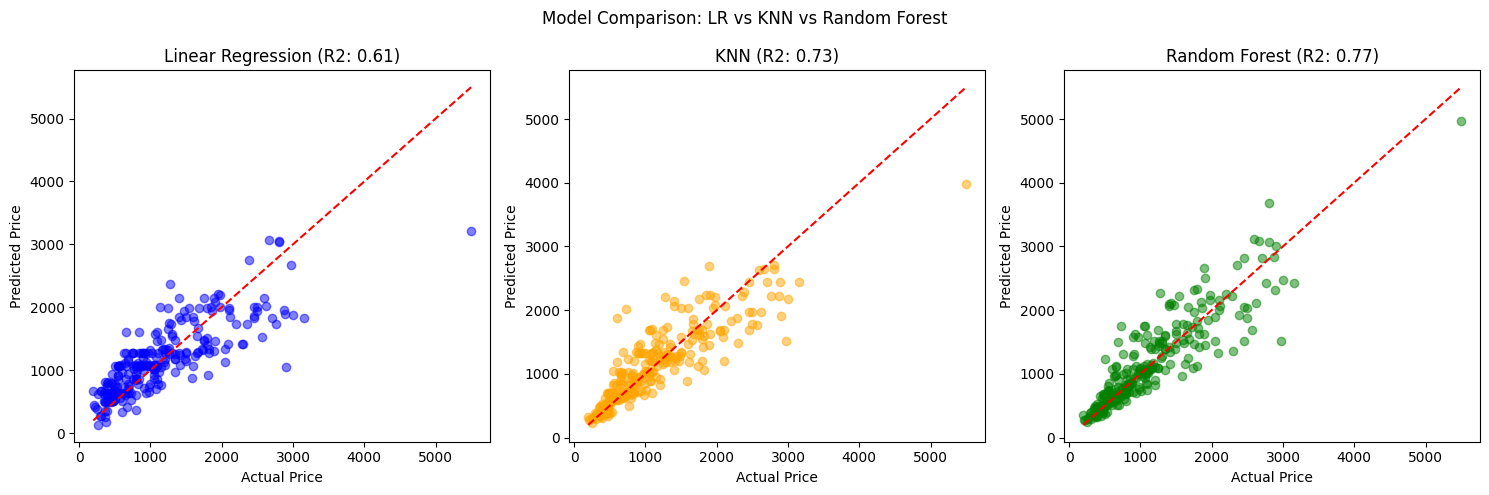

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(y_test, y_pred, alpha=0.5, color='blue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_title('Linear Regression (R2: 0.61)')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')

ax2.scatter(y_test, knn_pred, alpha=0.5, color='orange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_title('KNN (R2: 0.73)')
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')

ax3.scatter(y_test, rf_pred, alpha=0.5, color='green')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax3.set_title('Random Forest (R2: 0.77)')
ax3.set_xlabel('Actual Price')
ax3.set_ylabel('Predicted Price')

plt.suptitle('Model Comparison: LR vs KNN vs Random Forest')
plt.tight_layout()
plt.show()